In [1]:
import cv2
import skimage
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation

In [2]:
from utils import find_active_player

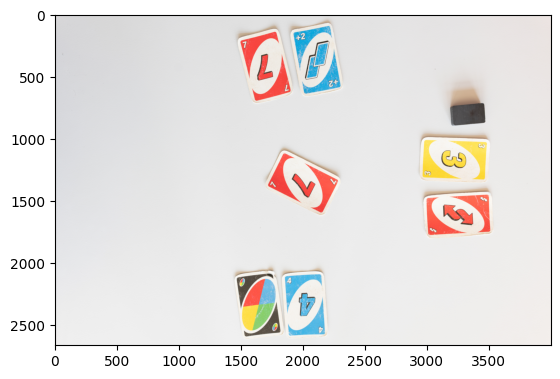

In [3]:
img = np.array(Image.open("./train_images/L1000777.jpg"))
plt.imshow(img)

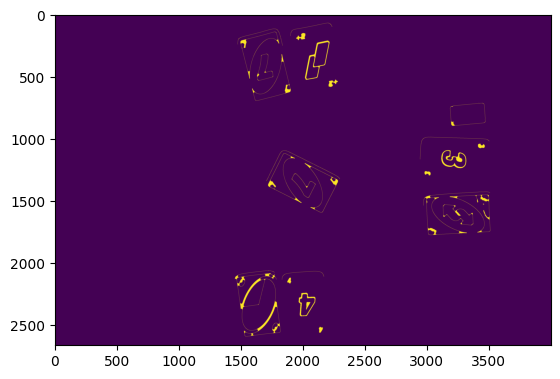

In [35]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (11,11), 0)

edges = cv2.Canny(blur, 50, 150)

kernel = disk(9)
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

plt.imshow(closed)

contours, _ = cv2.findContours(
    closed,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for cnt in contours:
    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)

In [4]:
find_active_player(img)

2


np.int64(2)